<a href="https://colab.research.google.com/github/parth-electron/All-Projects/blob/main/Lunar%20Lander%20RL%20Agent%20Training/Assignmentx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
Starting DQN training on LunarLander-v3...

Note: LunarLander is harder than CartPole and may take a while (hundreds to 1000+ episodes) to reach a strong solution.

Episode   20 | Reward:  -123.0 | Avg(last 20):  -162.9 | Epsilon: 0.916
Episode   40 | Reward:   -94.2 | Avg(last 40):  -156.7 | Epsilon: 0.829
Episode   60 | Reward:  -200.6 | Avg(last 60):  -148.4 | Epsilon: 0.743
Episode   80 | Reward:   -69.1 | Avg(last 80):  -135.9 | Epsilon: 0.663
Episode  100 | Reward:   -12.6 | Avg(last 100):  -120.9 | Epsilon: 0.578
Episode  120 | Reward:   -23.1 | Avg(last 100):   -98.5 | Epsilon: 0.468
Episode  140 | Reward:  -114.3 | Avg(last 100):   -82.4 | Epsilon: 0.250
Episode  160 | Reward:   -33.2 | Avg(last 100):   -65.3 | Epsilon: 0.124
Episode  180 | Reward:   -18.0 | Avg(last 100):   -46.8 | Epsilon: 0.052
Episode  200 | Reward:   -40.1 | Avg(last 100):   -23.3 | Epsilon: 0.029
Episode  220 | Reward:   -53.0 | Avg(last 100):    -8.9 | Epsilon: 0.018
Episode  240 | Re

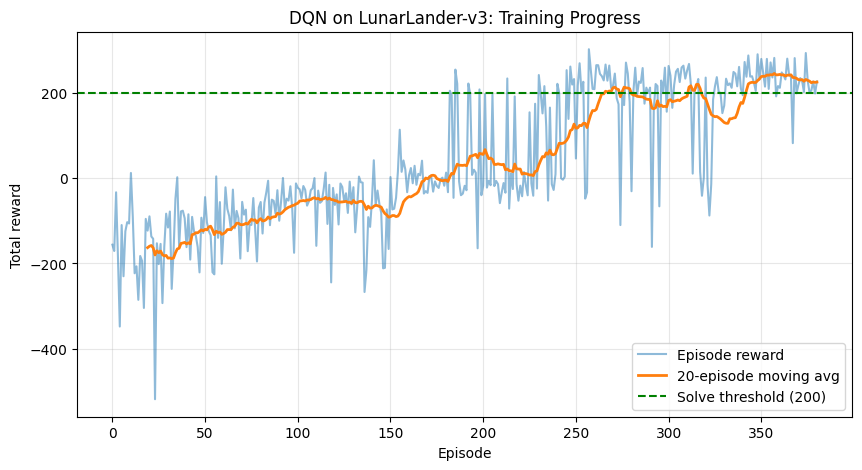


Running greedy evaluation over 20 episodes...
Evaluation scores: [np.float64(228.03716014431507), np.float64(228.66138766866612), np.float64(255.73744229709524), np.float64(250.01761347511754), np.float64(245.3729046429585), np.float64(278.1620099052859), np.float64(215.78278372061914), np.float64(234.1081317177841), np.float64(241.86752225782342), np.float64(217.99471746442953), np.float64(256.2418703543516), np.float64(246.37394506343892), np.float64(267.73129167351243), np.float64(210.57330754079726), np.float64(236.02602266880874), np.float64(239.84923082857347), np.float64(237.0889167385782), np.float64(247.27498176463678), np.float64(209.26037430509695), np.float64(219.11253013173803)]
Average evaluation score: 238.26 (std: 18.10, max: 278.2, min: 209.3)

Results saved to: lunarlander_results/run_20260723_070418
  - Model weights   : lunarlander_results/run_20260723_070418/dqn_lunarlander.pth
  - Episode rewards : lunarlander_results/run_20260723_070418/episode_rewards.csv
  - E

In [1]:


# ----------------------------------------------------------------------
# 0. Install dependencies (safe to run multiple times / already installed)
# ----------------------------------------------------------------------
import subprocess
import sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for _pkg in ["swig", "gymnasium[box2d]", "torch", "numpy", "matplotlib"]:
    try:
        _pip_install(_pkg)
    except Exception as e:
        print(f"Warning: could not install {_pkg}: {e}")

# ----------------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------------
import os
import csv
import math
import random
from datetime import datetime
from collections import deque, namedtuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import gymnasium as gym

# ----------------------------------------------------------------------
# 2. Reproducibility & device
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ENV_ID = "LunarLander-v3"

# ----------------------------------------------------------------------
# 3. Q-Network
# ----------------------------------------------------------------------
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)


# ----------------------------------------------------------------------
# 4. Replay Buffer
# ----------------------------------------------------------------------
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


# ----------------------------------------------------------------------
# 5. DQN Agent
# ----------------------------------------------------------------------
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim

        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=5e-4)
        self.buffer = ReplayBuffer()

        self.gamma = 0.99
        self.batch_size = 128
        self.min_buffer_size = 2000

        self.eps_start = 1.0
        self.eps_end = 0.01
        self.eps_decay = 20000  # steps (LunarLander needs longer exploration)
        self.steps_done = 0

        self.target_update_every = 1000  # gradient steps
        self.update_count = 0

    def epsilon(self):
        return self.eps_end + (self.eps_start - self.eps_end) * math.exp(
            -1.0 * self.steps_done / self.eps_decay
        )

    def select_action(self, state, greedy=False):
        eps = self.epsilon()
        self.steps_done += 1
        if (not greedy) and random.random() < eps:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = self.policy_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def store(self, *args):
        self.buffer.push(*args)

    def train_step(self):
        if len(self.buffer) < max(self.batch_size, self.min_buffer_size):
            return None

        batch = self.buffer.sample(self.batch_size)

        states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
        actions = torch.tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
        rewards = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
        dones = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

        q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1, keepdim=True)[0]
            target = rewards + self.gamma * next_q_values * (1 - dones)

        loss = nn.functional.smooth_l1_loss(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)
        self.optimizer.step()

        self.update_count += 1
        if self.update_count % self.target_update_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()


# ----------------------------------------------------------------------
# 6. Training loop
# ----------------------------------------------------------------------
def train(num_episodes=1200, max_steps=1000, solve_score=200.0, solve_window=100):
    """
    LunarLander-v3 is considered solved when the average reward over
    100 consecutive episodes is >= 200.
    """
    env = gym.make(ENV_ID)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DQNAgent(state_dim, action_dim)

    episode_rewards = []
    recent_rewards = deque(maxlen=solve_window)
    solved_at = None

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset(seed=SEED + episode)
        total_reward = 0.0

        for t in range(max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.store(state, action, reward, next_state, float(done))
            agent.train_step()

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)
        recent_rewards.append(total_reward)
        avg_recent = np.mean(recent_rewards)

        if episode % 20 == 0:
            print(
                f"Episode {episode:4d} | Reward: {total_reward:7.1f} | "
                f"Avg(last {len(recent_rewards)}): {avg_recent:7.1f} | "
                f"Epsilon: {agent.epsilon():.3f}"
            )

        if solved_at is None and len(recent_rewards) == solve_window and avg_recent >= solve_score:
            solved_at = episode
            print(f"\nSolved! Environment solved in {episode} episodes "
                  f"(avg reward {avg_recent:.1f} over last {solve_window} episodes).\n")
            break

    env.close()
    return agent, episode_rewards, solved_at


# ----------------------------------------------------------------------
# 7. Evaluation
# ----------------------------------------------------------------------
def evaluate(agent, num_episodes=20, max_steps=1000):
    env = gym.make(ENV_ID)
    scores = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=5000 + episode)
        total_reward = 0.0
        for t in range(max_steps):
            action = agent.select_action(state, greedy=True)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        scores.append(total_reward)

    env.close()
    return scores


# ----------------------------------------------------------------------
# 8. Plotting
# ----------------------------------------------------------------------
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, label="Episode reward", alpha=0.5)

    if len(rewards) >= 20:
        window = 20
        moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")
        plt.plot(range(window - 1, len(rewards)), moving_avg, label=f"{window}-episode moving avg", linewidth=2)

    plt.axhline(y=200, color="green", linestyle="--", label="Solve threshold (200)")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("DQN on LunarLander-v3: Training Progress")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# ----------------------------------------------------------------------
# 9. Save results (model checkpoint, reward CSV, plot image, summary)
# ----------------------------------------------------------------------
def save_results(agent, reward_history, eval_scores, out_dir="lunarlander_results"):
    """
    Saves everything needed to inspect or reuse a training run:
      - policy_net weights (.pth)
      - per-episode rewards (.csv)
      - evaluation scores (.csv)
      - training curve (.png)
      - a short summary (.txt)
    In Colab, files are written to the local runtime disk. To persist them,
    either download via files.download(...) (uncomment below) or mount Drive.
    """
    os.makedirs(out_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(out_dir, f"run_{timestamp}")
    os.makedirs(run_dir, exist_ok=True)

    # 1) Model weights
    model_path = os.path.join(run_dir, "dqn_lunarlander.pth")
    torch.save(agent.policy_net.state_dict(), model_path)

    # 2) Episode rewards CSV
    rewards_path = os.path.join(run_dir, "episode_rewards.csv")
    with open(rewards_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["episode", "reward"])
        for i, r in enumerate(reward_history, start=1):
            writer.writerow([i, r])

    # 3) Evaluation scores CSV
    eval_path = os.path.join(run_dir, "eval_scores.csv")
    with open(eval_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["eval_episode", "score"])
        for i, s in enumerate(eval_scores, start=1):
            writer.writerow([i, s])

    # 4) Training curve image
    plot_path = os.path.join(run_dir, "training_curve.png")
    plt.figure(figsize=(10, 5))
    plt.plot(reward_history, label="Episode reward", alpha=0.5)
    if len(reward_history) >= 20:
        window = 20
        moving_avg = np.convolve(reward_history, np.ones(window) / window, mode="valid")
        plt.plot(range(window - 1, len(reward_history)), moving_avg,
                  label=f"{window}-episode moving avg", linewidth=2)
    plt.axhline(y=200, color="green", linestyle="--", label="Solve threshold (200)")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("DQN on LunarLander-v3: Training Progress")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.close()

    # 5) Summary text file
    summary_path = os.path.join(run_dir, "summary.txt")
    with open(summary_path, "w") as f:
        f.write("LunarLander-v3 DQN Training Summary\n")
        f.write("====================================\n")
        f.write(f"Timestamp: {timestamp}\n")
        f.write(f"Episodes trained: {len(reward_history)}\n")
        tail = reward_history[-100:] if len(reward_history) >= 100 else reward_history
        f.write(f"Final {len(tail)}-episode avg reward: {np.mean(tail):.2f}\n")
        f.write(f"Evaluation (greedy) avg score: {np.mean(eval_scores):.2f}\n")
        f.write(f"Evaluation (greedy) std: {np.std(eval_scores):.2f}\n")
        f.write(f"Evaluation (greedy) max: {np.max(eval_scores):.1f}\n")
        f.write(f"Evaluation (greedy) min: {np.min(eval_scores):.1f}\n")

    print(f"\nResults saved to: {run_dir}")
    print(f"  - Model weights   : {model_path}")
    print(f"  - Episode rewards : {rewards_path}")
    print(f"  - Eval scores     : {eval_path}")
    print(f"  - Training plot   : {plot_path}")
    print(f"  - Summary         : {summary_path}")

    # Optional: uncomment to auto-download the whole folder as a zip in Colab
    # import shutil
    # from google.colab import files
    # zip_path = shutil.make_archive(run_dir, "zip", run_dir)
    # files.download(zip_path)

    return run_dir


# ----------------------------------------------------------------------
# 10. Main
# ----------------------------------------------------------------------
if __name__ == "__main__":
    print("Starting DQN training on LunarLander-v3...\n")
    print("Note: LunarLander is harder than CartPole and may take a while "
          "(hundreds to 1000+ episodes) to reach a strong solution.\n")

    trained_agent, reward_history, solved_episode = train(
        num_episodes=1200,
        max_steps=1000,
        solve_score=200.0,
        solve_window=100,
    )

    print("\nTraining finished.")
    if solved_episode:
        print(f"Environment considered SOLVED at episode {solved_episode}.")
    else:
        print("Environment was not formally 'solved' within the episode budget, "
              "but the agent may still perform reasonably well. Check the plot / eval scores. "
              "Consider increasing num_episodes if the reward trend is still improving.")

    plot_rewards(reward_history)

    print("\nRunning greedy evaluation over 20 episodes...")
    eval_scores = evaluate(trained_agent, num_episodes=20, max_steps=1000)
    print(f"Evaluation scores: {eval_scores}")
    print(f"Average evaluation score: {np.mean(eval_scores):.2f} "
          f"(std: {np.std(eval_scores):.2f}, max: {np.max(eval_scores):.1f}, min: {np.min(eval_scores):.1f})")

    save_results(trained_agent, reward_history, eval_scores)